In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats

# GARCH Stylised Facts
- GARCH implementation
- Evidence of no autocorrelation
- Evidence of significant persistence
- Evidence of heavy tails

## GARCH(1,1) Process

$$
Z_t \sim N(0, 1) \\
X_t = \sigma_t Z_t \\
\begin{aligned}
\sigma^2_t &= \alpha_0 + \alpha_1 X_{t-1}^2 + \beta_1 \sigma^2_{t-1} \\
&= \alpha_0 + \sigma^2_{t-1}(\alpha_1 Z_{t-1}^2 + \beta_1)
\end{aligned}
$$

In [2]:
def iter(X, sigma, a0, a1, b1):
    '''Single Garch Iteration'''
    
    # Sigma Iteration
    sigma_iter = a0 + a1*X[-1]**2 + b1*sigma[-1]
    sigma = np.append(sigma, sigma_iter)
    
    # X Iteration
    Z = np.random.normal(0, 1)
    X_iter = np.sqrt(sigma[-1]) * Z
    X = np.append(X, X_iter)
    
    return X, sigma

In [3]:
def GARCH(X0, sigma0, a0, a1, b1, niter):
    '''Random GARCH Process'''
    
    # Initialise Arrays
    X = np.array([X0])
    sigma = np.array([sigma0])
    
    # Compute Iterations
    for i in range(niter + 499):
        X, sigma = iter(X, sigma, a0, a1, b1)
        
    # Remove Values before Stationary
    X = pd.DataFrame({'X': X, 'Sigma^2': sigma}).drop(range(500))
    X.index = X.index-499
    
    return X

## Autocorrelation Testing

$$
\hat\rho(\tau) = \text{corr}(X_t,X_{t - \tau}) \\
\hat\rho_2(\tau) = \text{corr}(|X_t|,|X_{t - \tau}|)
$$


(-0.1, 0.1)

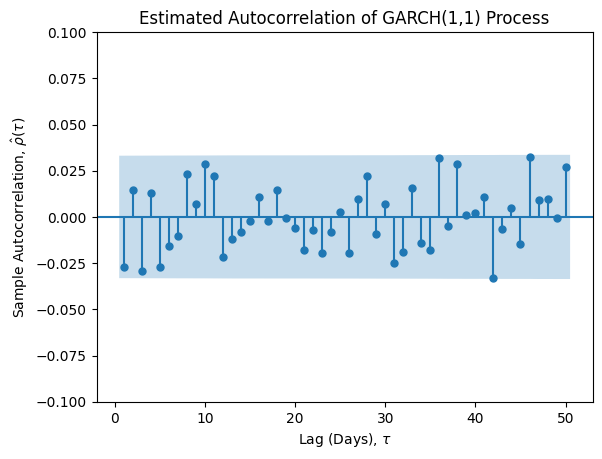

In [9]:
# ACF Graph GARCH
np.random.seed(3)
X = GARCH(0.01, 0.01, 0.001, 0.1035, 0.8650, 3500)

sm.graphics.tsa.plot_acf(X['X'], lags=50, zero=False, title='Estimated Autocorrelation of GARCH(1,1) Process')
plt.ylabel(r'Sample Autocorrelation, $\hat{\rho}(\tau)$')
plt.xlabel(r'Lag (Days), $\tau$')
plt.ylim([-0.1, 0.1])

(-0.1, 0.3)

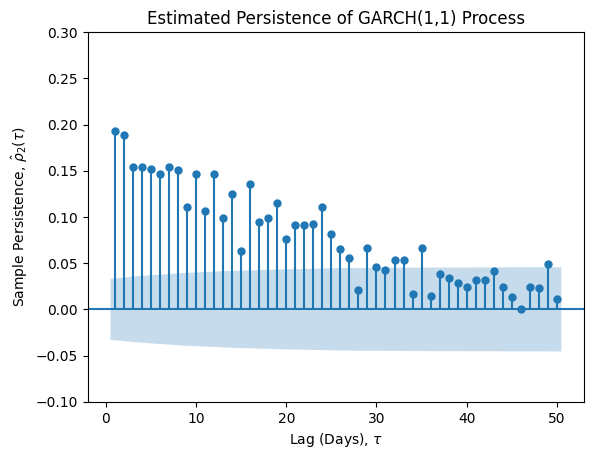

In [10]:
# Persistence Graph GARCH
np.random.seed(3)
X = GARCH(0.01, 0.01, 0.001, 0.1035, 0.8650, 3500)

sm.graphics.tsa.plot_acf(np.abs(X['X']), lags=50, zero=False, title='Estimated Persistence of GARCH(1,1) Process')
plt.ylabel(r'Sample Persistence, $\hat{\rho}_2(\tau)$')
plt.xlabel(r'Lag (Days), $\tau$')
plt.ylim([-0.1, 0.3])

## Heavy Tails

Text(0.5, 1.0, 'Normal QQ-Plot for Simulated GARCH Values')

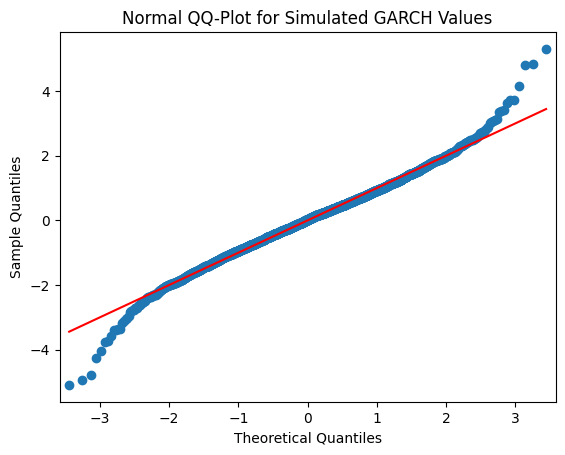

In [11]:
# QQ-Plot GARCH
sm.qqplot(X['X'].sort_values(), stats.norm, fit=True, line='s')
plt.title('Normal QQ-Plot for Simulated GARCH Values')